# ILC method

After the first two steps:
1. Analythical work on g($\nu$),
2. Simultaions of tSZ + $\mu$-distorted tSZ + CMB + noise signals,

I will start implementing the ILC method.

This code must

1. Compute the correlation matrix: $$C_{ij} = \frac{1}{N_P} \Sigma_{p'} \left( d_i(p') \cdot d_j(p') \right)$$
(i.e. i,j = 1, ..., 20)

2. Invert the correlation matrix: $$\underline{\underline{C}} \rightarrow \underline{\underline{C^{-1}}}$$

3. Compute the weights: $$\underline{\omega} = \frac{\underline{\underline{C^{-1}}} \cdot \underline{g}}{\underline{g^\intercal} \cdot \underline{\underline{C^{-1}}} \cdot \underline{g}}$$

4. Apply the weights ($\omega_i$) to the data ($d_i$).

5. Get the output: $$\hat{y} = \Sigma_i \left( \omega_i \cdot d_i (p) \right)$$

### Previous

In [1]:
### IMPORT PACKAGES ###

import healpy as hp
import numpy as np
import pandas as pd
import scipy as sp
import numba as nb
import matplotlib.pyplot as plt

import gc
from joblib import Parallel, delayed
from numba import njit, prange
from scipy.interpolate import *
from scipy import stats

from astropy.wcs import WCS
from reproject import reproject_from_healpix

In [2]:
### MEMORY MANAGEMENT ###

import gc # Garbage Collector

# Before starting a new run, clear previous big variables if they exist
if 'data_cube' in locals():
    del data_cube
if 'alms_list' in locals():
    del alms_list
if 'y_hat_harmonic' in locals():
    del y_hat_harmonic
if 'y_hat_pixel' in locals():
    del y_hat_pixel

gc.collect() # Manually trigger memory cleanup

32

In [3]:
### DEFINITIONS: CONSTANTS, FREQUENCIES, ETC. ###

# Nside
nside_work = 2048

# Conversion factor for Compton-y to muK
T_cmb_muK = 2.7255e6

# Planck frequencies in GHz --- kickoff diapo. 8
frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857]

# Reference noise
base_sensitivity_uk_arcmin = 2.0
#base_sensitivity_uk_arcmin = 30.0

# Theoretical (LCDM) mu-distortion value
mu = 2e-8

# Calculate area of pixel in arcmin^2 for the working resolution. As hp.nside2pixarea gives us the area in steradians, we convert it to arcmin^2 by multiplying by (180*60/pi)^2
pixel_area_arcmin2 = hp.nside2pixarea(nside_work) * (180*60/np.pi)**2

### Pipeline

In [4]:
### 1. Load the processed Maps and the data_cube ###

# Raw data: https://lambda.gsfc.nasa.gov/simulation/mocks_data.html

path_to_websky = '/Users/joanribot/HEAVY_STUFF/TFM_data/Processed_Maps/'

print("Loading the y_map, cmb_map and data_cube (4 layers: CMB + tSZ + noise + mu-distorted tSZ) from file...")

# A. Load the Data Cube (The 'Observed' (simulated) data)
data_cube = hp.read_map(path_to_websky + "data_cube_9freq.fits", field=None).astype(np.float32)

# B. Load the Truth Maps (For validation and residuals)
y_map = hp.read_map(path_to_websky + "y_map.fits").astype(np.float32)
cmb_map = hp.read_map(path_to_websky + "cmb_map.fits").astype(np.float32)

print(f"Data Cube loaded. Shape: {data_cube.shape}")
print(f"{data_cube.shape[0]} frequencies: {frequencies} with 4 layer maps of {data_cube.shape[1]} pixels as Nside = {nside_work}.")
# Should be (9, 50331648) for Nside 2048

Loading the y_map, cmb_map and data_cube (4 layers: CMB + tSZ + noise + mu-distorted tSZ) from file...
Data Cube loaded. Shape: (9, 50331648)
9 frequencies: [30, 44, 70, 100, 143, 217, 353, 545, 857] with 4 layer maps of 50331648 pixels as Nside = 2048.


In [5]:
### 2. Define the tSZ frequency scaling function g(nu) and Taylor expansion h(nu) ###

def get_physics_constants(nu):
    """Calculate the physics constants needed for tSZ scaling."""
    T_cmb = 2.7255     # CMB temperature in K
    k_B = 1.380649e-23 # Boltzmann constant in J/K
    h = 6.62607015e-34 # Planck constant in J*s
    x = (h * nu * 1e9) / (k_B * T_cmb) # Dimensionless frequency
    return x

def get_tsz_g(nu):
    """Calculate the tSZ frequency scaling g(nu) in dimensionless units."""
    x = get_physics_constants(nu)
    g_nu = x * (np.exp(x) + 1) / (np.exp(x) - 1) - 4 # or alternatively: g_nu = x * (1 / np.tanh(x / 2)) - 4
    return g_nu

def get_tsz_h(nu):
    """Calculate the tSZ Taylor expansion frequency scaling h(nu) in dimensionless units."""
    x = get_physics_constants(nu)
    h_nu = (-x/2) * ( 1 / ( (np.exp(x) - np.exp(-x)) / 2 )**2 ) # or alternatively: h_nu = (-x/2) * (1 / np.sinh(x/2)**2)
    #h_nu = (-x/2) * (1 / np.sinh(x/2)**2)
    return h_nu

# ILC implementation

### Outline:

1. ILC method definition: Pixel ILC (P-ILC) & Harmonic ILC (H-ILC).


2. Processing for each signal:

| **Subsection** | __Signal__ | **SED** | **Extracted map** |
| :---: | :---: | :---: | :---: |
| 2.1. | tSZ | $g(\nu) = x \coth \left( \frac{x}{2} \right) - 4 $ | $y$-map |
| 2.2. | CMB | $a=[1,...,1]$ | $CMB$-map |
| 2.3. | $\mu$-distorted tSZ | $h(\nu) = - \frac{x}{2} \frac{1}{\sinh^2\left( \frac{x}{2} \right)}$ | $\mu y$-map |

where $x \equiv \frac{h \nu}{k_B T_{CMB}}$.

3. Plotting two views for every map:
- Zoomed view.
- Mollweide view.

4. Extra plots.

5. TT map: $\mu y$ Vs. $y$ for $\mu$ extraction.

## 1. ILC method definition

In [6]:
def run_pixel_ilc(data_cube, vector_muK): ### UNITLESS MAP OUTPUT + WEIGHTS ###

    # C definition
    n_freq, n_pix = data_cube.shape
    C = (1.0 / n_pix) * (data_cube @ data_cube.T) # IS IT THAT d_i (p') * d_j (p') = data_cube @ data_cube.T
    C_inv = np.linalg.pinv(C)

    # Calculate the weights
    weights = (C_inv @ vector_muK) / (vector_muK.T @ C_inv @ vector_muK)

    return weights @ data_cube, weights

# weights @ data_cube IS UNITLESS AS [weights] = 1/g^t * data_cube = 1/T_cmb * T_cmb
# [g] = T_cmb_muK
# [data_cube] = T_cmb_muK

In [ ]:
def run_harmonic_ilc_with_weights(data_cube, vector_muK, l_bins): ### UNITLESS MAP OUTPUT + WEIGHTS PER BIN  ###
    """Advanced Harmonic-Space ILC (Multi-scale)"""
    n_freq, n_pix = data_cube.shape
    nside = hp.npix2nside(n_pix)
    lmax = 3*nside-1
    alms_list = [hp.map2alm(m, lmax=lmax) for m in data_cube]
    final_alms = np.zeros(hp.Alm.getsize(lmax), dtype=np.complex128)
    ell, _ = hp.Alm.getlm(lmax)
    
    # NEW: Matrix to store weights for each bin
    weights_per_bin = []

    for i in range(len(l_bins)-1):
        mask = (ell >= l_bins[i]) & (ell < l_bins[i+1])
        bin_alms = np.array([alms[mask] for alms in alms_list])
        cov_bin = np.real(np.conj(bin_alms) @ bin_alms.T) / np.sum(mask)
        inv_cov = np.linalg.pinv(cov_bin)
        
        # Calculate weights for THIS specific scale
        w_bin = (inv_cov @ vector_muK) / (vector_muK.T @ inv_cov @ vector_muK)
        weights_per_bin.append(w_bin) # Store them
        
        final_alms[mask] = w_bin @ bin_alms
        
    return hp.alm2map(final_alms, nside=nside), np.array(weights_per_bin)

## 2.1. tSZ signal: $g(\nu) \rightarrow$ ($y$-map)

Execute both P-ILC & H-ILC methods separetly for the seek of time. Harmonic-space is more time consuming as more bins are considered.

In [7]:
### Define the g_vector_muK ###

# Define g_vector (and h_vector) in muK units for the frequencies in the data cube
g_vector_muK = np.array([get_tsz_g(nu) for nu in frequencies]) * T_cmb_muK # IT HAS TO BE MULTIPLIED BY T_CMB * 10^6 or T_CMB_MU_K

# If we wanted to do the same for h_vector (for the mu distorted tSZ signal ILC), we would do:
#h_vector_muK = np.array([get_tsz_h(nu) for nu in frequencies]) * T_cmb_muK

In [8]:
### See the g_vector values for the frequencies ### 

print(g_vector_muK/T_cmb_muK) # Should be unitless and match the expected g(nu) values for the frequencies

[-1.95370510e+00 -1.90093913e+00 -1.75296860e+00 -1.50810042e+00
 -1.04036374e+00 -7.77511465e-03  2.24074262e+00  5.59802958e+00
  1.10906388e+01]


In [9]:
### Check lengths of the vectors and frequencies ###

print(len(g_vector_muK)) # Should be 9, one for each frequency
print(len(frequencies)) # Should be 9, one for each frequency

9
9


In [10]:
### P-ILC ###

# Run P-ILC. The resulting map is unitless.
y_hat_pixel_ilc, w_pixel_y_ilc = run_pixel_ilc(data_cube, g_vector_muK)

# Calculate the residual in dimensionless y units (Truth - Reconstruction)
y_residual_pixel_ilc = y_map - y_hat_pixel_ilc

"""
# As y_map is also unitless, I will leave both unitless. However, I could aslo convert both to muK units and have a 10^5 scale factor.
y_map_muK = y_map * T_cmb_muK
y_residual_pixel_muK = y_map_muK - y_hat_pixel_ilc * T_cmb_muK
"""

# Validation: Both should be order 10^-5
print(f"Truth max: {np.max(y_map):.2e}")
print(f"Reco max: {np.max(y_hat_pixel_ilc):.2e}")
print(f"Residual max: {np.max(y_residual_pixel_ilc):.2e}")

Truth max: 1.99e-04
Reco max: 2.00e-04
Residual max: 6.08e-06


In [11]:
### P-ILC WEIGHTS ANALYSIS ###

df_weights_pixel_ilc = pd.DataFrame({
    'Freq (GHz)': frequencies,
    'Weight': w_pixel_y_ilc,
    'g(nu) * T_cmb_muK': g_vector_muK
})
# Transpose it for horizontal display
df_horizontal_pixel_ilc = df_weights_pixel_ilc.set_index('Freq (GHz)').T
pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)
print("--- P-ILC Analysis Weights ---")
print(df_horizontal_pixel_ilc)
print()

# Verify the constraint is satisfied
constraint_check_pixel_ilc = np.sum(w_pixel_y_ilc * g_vector_muK)
w_pixel_y_sum = np.sum(w_pixel_y_ilc)
print(f"Constraint Check: {constraint_check_pixel_ilc:.4f}")
print(f"Sum of Weights: {w_pixel_y_sum:.4f}")
print("Great! Since the CMB has the same value in every channel, the ILC 'subtracts' the low-frequency channels from the high-frequency ones to make the CMB disappear.")

--- P-ILC Analysis Weights ---
Freq (GHz)                  30            44            70            100           143           217           353           545           857
Weight            -1.585149e-08 -1.060269e-08 -6.946324e-09 -4.219674e-09 -1.732386e-09  1.492428e-09  6.453846e-09  1.195306e-08  1.930231e-08
g(nu) * T_cmb_muK -5.324823e+06 -5.181010e+06 -4.777716e+06 -4.110328e+06 -2.835511e+06 -2.119107e+04  6.107144e+06  1.525743e+07  3.022754e+07

Constraint Check: 1.0000
Sum of Weights: -0.0000
Great! Since the CMB has the same value in every channel, the ILC 'subtracts' the low-frequency channels from the high-frequency ones to make the CMB disappear.


In [ ]:
### H-ILC (with weights) ###

# Extended range to capture high-resolution cluster details
l_bins = [2, 25, 50, 75, 100, 150, 200, 300, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500]

# Calculate the harmonic ILC reconstruction and get the weights for each bin
y_hat_harmonic, weights_y_harmonic_bins = run_harmonic_ilc_with_weights(data_cube, g_vector_muK, l_bins)

# Residual map in muK units for harmonic ILC
y_residual_harmonic = y_map - y_hat_harmonic


"""
Again, I could convert both to muK units and have a 10^5 scale factor, but I will leave them unitless for consistency with the pixel ILC.
y_map_muK = y_map * T_cmb_muK
y_residual_harmonic_muK = y_map_muK - y_hat_harmonic * T_cmb_muK
"""

# Validation: Both should be order 10^-5
print(f"Number of bins: {len(l_bins)}")
print(f"Truth max: {np.max(y_map):.2e}")
print(f"Reco max: {np.max(y_hat_harmonic):.2e}")
print(f"Residual max: {np.max(y_residual_harmonic):.2e}")

## 3.1. P-ILC & H-ILC: $y$-maps

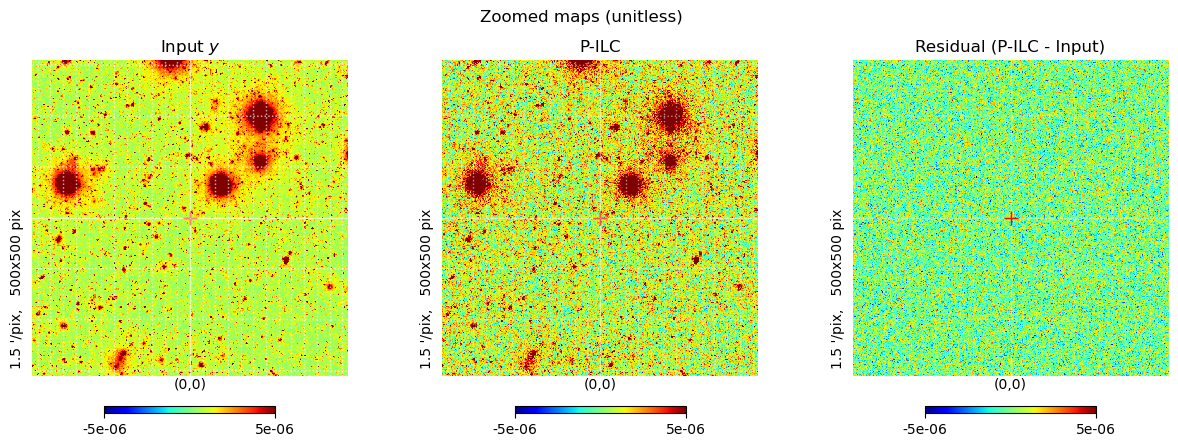

In [12]:
### A.1. PIXEL ILC ZOOMED MAPS ###

params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-6, 'max': 5*10**-6} # Added 'coord': 'G' to specify Galactic coordinates
#params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(1, 3, 1)
hp.gnomview(y_map, title="Input $y$", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.gnomview(y_hat_pixel_ilc, title="P-ILC", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.gnomview(y_residual_pixel_ilc, title="Residual (P-ILC - Input)", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle("Zoomed maps (unitless)")
plt.savefig("Figures/ILC/y_maps/P-ILC_zoomed_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

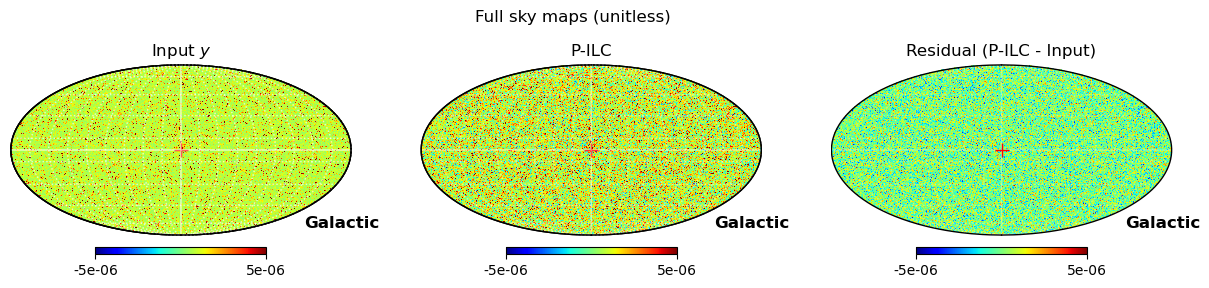

In [13]:
### A.2. PIXEL ILC FULL SKY MAPS ###

params_moll = {'coord': ['G'], 'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-6, 'max': 5*10**-6}
#params_moll = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 3))

ax1 = plt.subplot(1, 3, 1)
hp.mollview(y_map, title="Input $y$", **params_moll)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.mollview(y_hat_pixel_ilc, title="P-ILC", **params_moll)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.mollview(y_residual_pixel_ilc, title="Residual (P-ILC - Input)", **params_moll)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle("Full sky maps (unitless)")
plt.savefig("Figures/ILC/y_maps/P-ILC_full_sky_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### A.3. PIXEL ILC FULL SKY MAPS - VERTICAL ###

# Increase the height of the figure (from 3 to 15) to accommodate the stack
fig_full = plt.figure(figsize=(8, 15))

params_moll = {
    'coord': ['G'], 
    'rot': [0, 0], 
    'hold': True, 
    'cmap': 'jet', 
    'notext': False, # Keep False so coordinate numbers are generated
    'min': -5*10**-6, 
    'max': 5*10**-6
}

maps = [y_map, y_hat_pixel, y_residual_pixel]
titles = ["Input $y$", "P-ILC", "Residual (P-ILC - Input)"]

for i, (m, t) in enumerate(zip(maps, titles)):
    # Change to 3 rows, 1 column
    ax = fig_full.add_subplot(3, 1, i+1)
    
    hp.mollview(m, title=t, **params_moll)
    hp.graticule(color='white', alpha=0.3)
    
    # Mark the center
    plt.plot(0, 0, marker='+', color='red', markersize=10)

    # Clean up metadata text (Mollweide, Nside, etc.) while keeping coordinate labels
    for text in ax.texts:
        content = text.get_text()
        if any(s in content for s in ["Mollweide", "Min", "Max", "Nside"]):
            text.set_visible(False)

# Adjust title position so it doesn't overlap the top plot
plt.suptitle("Full sky maps (unitless)", fontsize=16, y=0.92)

# Save and show
#plt.savefig("Figures/PILC_full_sky_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### B.1. HARMONIC ILC ZOOMED MAPS ###

params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-6, 'max': 5*10**-6}
#params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 600, 'hold': True, 'cmap': 'jet', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
#hp.gnomview(y_map_muK, title="Harmonic ILC: Full Sky (y)", **params_zoom)
hp.gnomview(y_map, title="Input $y$", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.subplot(1, 3, 2)
#hp.gnomview(y_hat_harmonic_muK, title="H-ILC", **params_zoom) ### NEXT TIME U COMPILE REMEMBER TO SWAP, I JUST SWAPED NAMES (_muK)
hp.gnomview(y_hat_harmonic, title="H-ILC", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.subplot(1, 3, 3)
#hp.gnomview(y_residual_harmonic_muK, title="Harmonic ILC: Residual (Truth - Reco)", **params_zoom)
hp.gnomview(y_residual_harmonic, title="Residual (H-ILC - Input)", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle("Zoomed maps (unitless)")
plt.savefig("Figures/ILC/y_maps/H-ILC_zoomed_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

l bin 4096

variance comparison on hilc and pilc

In [ ]:
### B.2. HARMONIC ILC FULL SKY MAPS ###

params_moll = {'coord': ['G'], 'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-6, 'max': 5*10**-6}
#params_moll = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 3))

plt.subplot(1, 3, 1)
#hp.mollview(y_map_muK, title="Harmonic ILC: Full Sky (y)", **params_moll)
hp.mollview(y_map, title="Input $y$", **params_moll)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.subplot(1, 3, 2)
#hp.mollview(y_hat_harmonic_muK, title="Harmonic ILC: Reconstruction", **params_moll) ### NEXT TIME U COMPILE REMEMBER TO SWAP, I JUST SWAPED NAMES (_muK)
hp.mollview(y_hat_harmonic, title="H-ILC", **params_moll)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.subplot(1, 3, 3)
#hp.mollview(y_residual_harmonic_muK, title="Harmonic ILC: Residual (Truth - Reco)", **params_moll)
hp.mollview(y_residual_harmonic, title="Residual (H-ILC - Input)", **params_moll)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle("Full sky maps (unitless)")
plt.savefig("Figures/ILC/y_maps/H-ILC_full_sky_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### B.3. HARMONIC WEIGHTS EVOLUTION ###

plt.figure(figsize=(10, 6))

# Define labels for the x-axis bins
bin_labels = [f"{l_bins[i]}-{l_bins[i+1]}" for i in range(len(l_bins)-1)]

for f_idx, nu in enumerate(frequencies):
    plt.plot(bin_labels, weights_y_harmonic_bins[:, f_idx], label=f"{nu} GHz", marker='o', linewidth=2)

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel(rf"Multipole Scale ($\ell$ bin)")
plt.ylabel("H-ILC Weight")
plt.title("Harmonic ILC weights evolution across scales")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig("Figures/ILC/y_maps/H-ILC_weights_evolution.pdf", dpi=300, bbox_inches='tight')
plt.show()

## 2.2. CMB signal: $a = [1,...,1] \rightarrow$ ($CMB$-map)

In [ ]:
### P-ILC ON THE CMB COMPONENT ###
a_cmb_muK = np.ones(len(frequencies)) * T_cmb_muK # CMB has the same amplitude in all frequencies, but we need to multiply by T_cmb_muK to have the correct units for the weights calculation, as the g_vector is in muK units. This way, the ILC will treat the CMB component with the correct scaling when calculating the weights.
signal_cmb = a_cmb_muK * cmb_map[:, np.newaxis]
# This will create a 2D array where each column is the CMB map (since a_cmb_muK is all ones, it just replicates the CMB map across all frequencies)

# Now we apply the ILC to the CMB signal alone to see if we can recover it
cmb_hat_pixel, weights_cmb = run_pixel_ilc(signal_cmb.T, a_cmb_muK) # We need to multiply a_cmb_muK by T_cmb_muK to have the correct units for the weights calculation

# Residual for the CMB reconstruction
cmb_residual_pixel = cmb_map - cmb_hat_pixel

In [ ]:
### H-ILC ON THE CMB COMPONENT ###
a_cmb_muK = np.ones(len(frequencies)) * T_cmb_muK # CMB has the same amplitude in all frequencies, but we need to multiply by T_cmb_muK to have the correct units for the weights calculation, as the g_vector is in muK units. This way, the ILC will treat the CMB component with the correct scaling when calculating the weights.
signal_cmb = a_cmb_muK * cmb_map[:, np.newaxis]
# This will create a 2D array where each column is the CMB map (since a_cmb_muK is all ones, it just replicates the CMB map across all frequencies)

# Extended range to capture high-resolution cluster details
l_bins = [2, 25, 50, 75, 100, 150, 200, 300, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500]

# Now we apply the ILC to the CMB signal alone to see if we can recover it
cmb_hat_harmonic, weights_cmb = run_harmonic_ilc_with_weights(signal_cmb.T, a_cmb_muK, l_bins) # We need to multiply a_cmb_muK by T_cmb_muK to have the correct units for the weights calculation

# Residual for the CMB reconstruction
cmb_residual_harmonic = cmb_map - cmb_hat_harmonic

## 3.2. P-ILC & H-ILC: $CMB$-maps

In [ ]:
### A.1. P-ILC CMB ZOOMED MAPS ###

# Define units: use 'r' before strings to avoid SyntaxWarnings with LaTeX \mu
unit_label = r"$\mu K_{CMB}$"

params_zoom_cmb = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -300, 'max': 300} # Added 'coord': 'G' to specify Galactic coordinates
params_zoom_cmb_residual = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -10, 'max': 10} # Added 'coord': 'G' to specify Galactic coordinates
#params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(1, 3, 1)
hp.gnomview(cmb_map, title="CMB input", unit=unit_label, **params_zoom_cmb)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='black', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.gnomview(cmb_hat_pixel, title="P-ILC CMB Reconstruction", unit=unit_label, **params_zoom_cmb)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='black', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.gnomview(cmb_residual_pixel, title="Residual (P-ILC - Input)", unit=unit_label, **params_zoom_cmb_residual)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='black', markersize=10, label='Center')

plt.suptitle("Zoomed maps (unitless)")
plt.savefig("Figures/ILC/CMB_maps/P-ILC_CMB_zoomed_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### A.2. P-ILC CMB FULL SKY MAPS ###

params_moll_cmb = {'coord': ['G'], 'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -300, 'max': 300}
params_moll_cmb_residuals = {'coord': ['G'], 'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -10, 'max': 10}
#params_moll = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 3))

ax1 = plt.subplot(1, 3, 1)
hp.mollview(cmb_map, title="CMB input", unit=unit_label, **params_moll_cmb)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='black', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.mollview(cmb_hat_pixel, title="P-ILC CMB Reconstruction", unit=unit_label, **params_moll_cmb)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='black', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.mollview(cmb_residual_pixel, title="Residual (P-ILC - Input)", unit=unit_label, **params_moll_cmb_residuals)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='black', markersize=10, label='Center')

plt.suptitle("Full sky maps (unitless)")
plt.savefig("Figures/ILC/CMB_maps/P-ILC_CMB_full_sky_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### B.1. H-ILC CMB ZOOMED MAPS ###

# Define units: use 'r' before strings to avoid SyntaxWarnings with LaTeX \mu
unit_label = r"$\mu K_{CMB}$"

params_zoom_cmb = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -300, 'max': 300} # Added 'coord': 'G' to specify Galactic coordinates
params_zoom_cmb_residual = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -10, 'max': 10} # Added 'coord': 'G' to specify Galactic coordinates
#params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(1, 3, 1)
hp.gnomview(cmb_map, title="CMB input", unit=unit_label, **params_zoom_cmb)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.gnomview(cmb_hat_harmonic, title="H-ILC CMB Reconstruction", unit=unit_label, **params_zoom_cmb)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.gnomview(cmb_residual_harmonic, title="Residual (H-ILC - Input)", unit=unit_label, **params_zoom_cmb_residual)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle("Zoomed maps (unitless)")
plt.savefig("Figures/ILC/CMB_maps/H-ILC_CMB_zoomed_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### B.2. H-ILC CMB FULL SKY MAPS ###

params_moll_cmb = {'coord': ['G'], 'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -300, 'max': 300}
#params_moll = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 3))

ax1 = plt.subplot(1, 3, 1)
hp.mollview(cmb_map, title="CMB input", unit=unit_label, **params_moll_cmb)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.mollview(cmb_hat_harmonic, title="H-ILC CMB Reconstruction", unit=unit_label, **params_moll_cmb)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.mollview(cmb_residual_harmonic, title="Residual (H-ILC - Input)", unit=unit_label, **params_moll_cmb_residuals)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle("Full sky maps (unitless)")
plt.savefig("Figures/ILC/CMB_maps/H-ILC_CMB_full_sky_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

## 2.3. $\mu$-distorted tSZ: $h(\nu) \rightarrow$ ($\mu y$-map)

In [14]:
### Define the h_vector_muK ###

# Define h_vector in muK units for the frequencies in the data cube
h_vector_muK = np.array([get_tsz_h(nu) for nu in frequencies]) * T_cmb_muK # IT HAS TO BE MULTIPLIED BY T_CMB * 10^6 or T_CMB_MU_K

In [15]:
### See the h_vector values for the frequencies ###

print(h_vector_muK/T_cmb_muK) # Should be unitless and match the expected h(nu) values for the frequencies

[-8.63164472e-01 -5.30353972e-01 -2.50250402e-01 -1.10494055e-01
 -3.31599993e-02 -3.67015123e-03 -4.96028711e-05 -8.86223773e-08
 -2.35603838e-12]


In [16]:
### Check lengths of the vectors and frequencies ###

print(len(h_vector_muK)) # Should be 9, one for each frequency
print(len(frequencies)) # Should be 9, one for each frequency

9
9


In [17]:
### P-ILC ON THE MU-DISTORTED tSZ SIGNAL ###

mu = 2e-8 # Dimensionless chemical potential for the mu-distortion

# Run P-ILC. The resulting map is unitless.
muy_hat_pixel_ilc, w_pixel_muy_ilc = run_pixel_ilc(data_cube, h_vector_muK)

muy_map = mu * y_map # The true mu-distorted tSZ signal in dimensionless units

# Calculate the residual in dimensionless mu*y units (Truth - Reconstruction)
muy_residual_pixel_ilc = muy_map - muy_hat_pixel_ilc

"""
# As y_map is also unitless, I will leave both unitless. However, I could also convert both to muK units and have a 10^5 scale factor.
muy_map_muK = muy_map * T_cmb_muK
residual_pixel_muK = muy_map_muK - muy_hat_pixel_ilc * T_cmb_muK
"""

# Validation: Both should be order 10^-13 (since mu is 10^-8 and y is 10^-5)
print(f"Truth max: {np.max(mu*y_map):.2e}")
print(f"Reco max: {np.max(muy_hat_pixel_ilc):.2e}")
print(f"Residual max: {np.max(muy_residual_pixel_ilc):.2e}")
print("WATCH!!! THERE IS A PROBLEM WITH RECO...")

Truth max: 3.99e-12
Reco max: 3.07e-04
Residual max: 5.33e-05
WATCH!!! THERE IS A PROBLEM WITH RECO...


---
STOP HERE - THE P-ILC ON THE MU-DISTORTED SIGNAL IS NOT WORKING
---
---

In [18]:
### P-ILC WEIGHTS ANALYSIS ###

df_weights_pixel_ilc_muy = pd.DataFrame({
    'Freq (GHz)': frequencies,
    'Weight': w_pixel_muy_ilc,
    'h(nu) * T_cmb_muK': h_vector_muK
})
# Transpose it for horizontal display
df_horizontal_pixel_ilc = df_weights_pixel_ilc_muy.set_index('Freq (GHz)').T
pd.set_option('display.expand_frame_repr', False) 
pd.set_option('display.max_columns', None)
print("--- P-ILC Analysis Weights ---")
print(df_horizontal_pixel_ilc)
print()

# Verify the constraint is satisfied
constraint_check_pixel_ilc = np.sum(w_pixel_muy_ilc * h_vector_muK)
w_pixel_muy_sum = np.sum(w_pixel_muy_ilc)
print(f"Constraint Check: {constraint_check_pixel_ilc:.4f}")
print(f"Sum of Weights: {w_pixel_muy_sum:.4f}")
#print("Great! Since the CMB has the same value in every channel, the ILC 'subtracts' the low-frequency channels from the high-frequency ones to make the CMB disappear.")

--- P-ILC Analysis Weights ---
Freq (GHz)                  30            44            70            100           143           217           353           545           857
Weight            -4.328956e-07 -6.579891e-08  9.476156e-08  1.243472e-07  1.164426e-07  9.098169e-08  5.611345e-08  2.243706e-08 -1.553982e-08
h(nu) * T_cmb_muK -2.352555e+06 -1.445480e+06 -6.820575e+05 -3.011515e+05 -9.037758e+04 -1.000300e+04 -1.351926e+02 -2.415403e-01 -6.421383e-06

Constraint Check: 1.0000
Sum of Weights: -0.0000


In [ ]:
### H-ILC ON THE MU-DISTORTED tSZ SIGNAL ###

# Extended range to capture high-resolution cluster details
l_bins = [2, 25, 50, 75, 100, 150, 200, 300, 500, 750, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500]

# Calculate the harmonic ILC reconstruction and get the weights for each bin
muy_hat_harmonic, weights_muy_harmonic_bins = run_harmonic_ilc_with_weights(data_cube, h_vector_muK * mu, l_bins)

# Residual map in mu*y units for harmonic ILC
muy_residual_harmonic = mu*y_map - muy_hat_harmonic

"""
Again, I could convert both to muK units and have a 10^5 scale factor, but I will leave them unitless for consistency with the pixel ILC.
muy_map_muK = muy_map * T_cmb_muK
muy_residual_harmonic = muy_map_muK - muy_hat_harmonic * T_cmb_muK
"""

# Validation: Both should be order 10^-13 (since mu is 10^-8 and y is 10^-5)
print(f"Number of bins: {len(l_bins)}")
print(f"Truth max: {np.max(mu*y_map):.2e}")
print(f"Reco max: {np.max(muy_hat_harmonic):.2e}")
print(f"Residual max: {np.max(muy_residual_harmonic):.2e}")

## 3.3. P-ILC & H-ILC: $\mu y$-maps

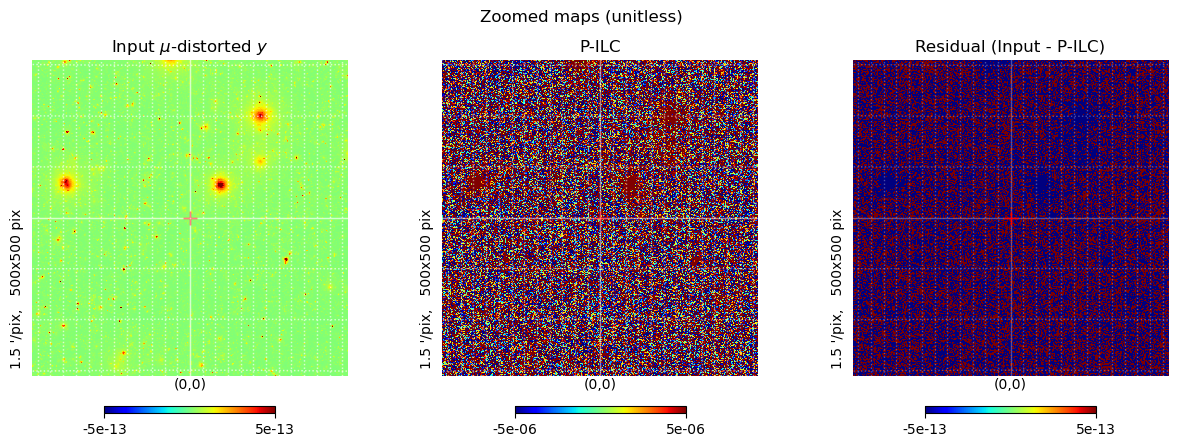

In [19]:
### A.1. PIXEL ILC ZOOMED MAPS ###

params_zoom_y = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-6, 'max': 5*10**-6} # Added 'coord': 'G' to specify Galactic coordinates
params_zoom_muy = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-13, 'max': 5*10**-13} # Added 'coord': 'G' to specify Galactic coordinates
#params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 5))

ax1 = plt.subplot(1, 3, 1)
hp.gnomview(muy_map, title=rf"Input $\mu$-distorted $y$", **params_zoom_muy)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.gnomview(muy_hat_pixel_ilc, title="P-ILC", **params_zoom_y)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.gnomview(muy_residual_pixel_ilc, title="Residual (Input - P-ILC)", **params_zoom_muy)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle("Zoomed maps (unitless)")
plt.savefig("Figures/ILC/mu_y_maps/P-ILC_zoomed_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

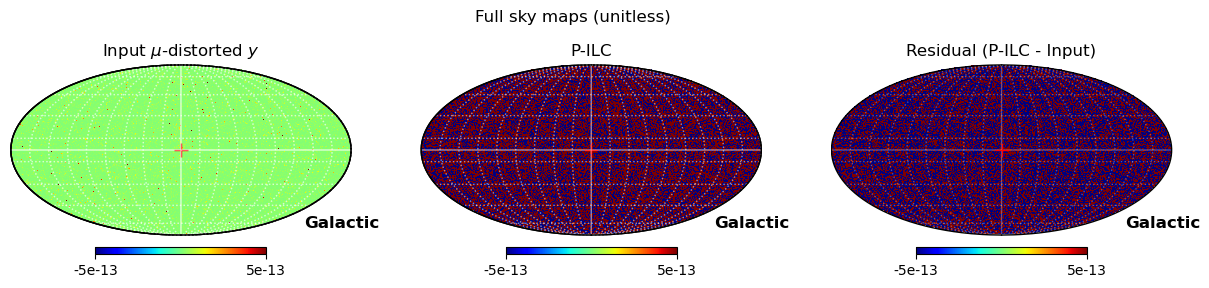

In [20]:
### A.2. PIXEL ILC FULL SKY MAPS ###

params_moll = {'coord': ['G'], 'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-13, 'max': 5*10**-13}
#params_moll = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'viridjetis', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 3))

ax1 = plt.subplot(1, 3, 1)
hp.mollview(muy_map, title=rf"Input $\mu$-distorted $y$", **params_moll)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax2 = plt.subplot(1, 3, 2)
hp.mollview(muy_hat_pixel_ilc, title="P-ILC", **params_moll)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

ax3 = plt.subplot(1, 3, 3)
hp.mollview(muy_residual_pixel_ilc, title="Residual (P-ILC - Input)", **params_moll)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle("Full sky maps (unitless)")
plt.savefig("Figures/ILC/mu_y_maps/P-ILC_full_sky_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### B.1. HARMONIC ILC ZOOMED MAPS ###

params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-13, 'max': 5*10**-13}
#params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 600, 'hold': True, 'cmap': 'jet', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 5))

plt.subplot(1, 3, 1)
#hp.gnomview(y_map_muK, title="Harmonic ILC: Full Sky (y)", **params_zoom)
hp.gnomview(muy_map, title=rf"Input $\mu$-distorted $y$", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.subplot(1, 3, 2)
#hp.gnomview(y_hat_harmonic_muK, title="H-ILC", **params_zoom) ### NEXT TIME U COMPILE REMEMBER TO SWAP, I JUST SWAPED NAMES (_muK)
hp.gnomview(muy_hat_harmonic, title="H-ILC", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.subplot(1, 3, 3)
#hp.gnomview(muy_residual_harmonic_muK, title="Harmonic ILC: Residual (Truth - Reco)", **params_zoom)
hp.gnomview(muy_residual_harmonic, title="Residual (H-ILC - Input)", **params_zoom)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle("Zoomed maps (unitless)")
plt.savefig("Figures/ILC/mu_y_maps/H-ILC_zoomed_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### B.2. HARMONIC ILC FULL SKY MAPS ###

params_moll = {'coord': ['G'], 'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': False, 'min': -5*10**-13, 'max': 5*10**-13}
#params_moll = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': True}

# --- Plotting ---
fig_harm = plt.figure(figsize=(15, 3))

plt.subplot(1, 3, 1)
#hp.mollview(y_map_muK, title="Harmonic ILC: Full Sky (y)", **params_moll)
hp.mollview(muy_map, title=rf"Input $\mu$-distorted $y$", **params_moll)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.subplot(1, 3, 2)
#hp.mollview(y_hat_harmonic_muK, title="Harmonic ILC: Reconstruction", **params_moll) ### NEXT TIME U COMPILE REMEMBER TO SWAP, I JUST SWAPED NAMES (_muK)
hp.mollview(muy_hat_harmonic, title="H-ILC", **params_moll)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.subplot(1, 3, 3)
#hp.mollview(muy_residual_harmonic_muK, title="Harmonic ILC: Residual (Truth - Reco)", **params_moll)
hp.mollview(muy_residual_harmonic, title="Residual (H-ILC - Input)", **params_moll)
hp.graticule(dpar=0.5, dmer=0.5, color='white', alpha=0.3)
plt.plot(0, 0, marker='+', color='red', markersize=10, label='Center')

plt.suptitle("Full sky maps (unitless)")
plt.savefig("Figures/ILC/mu_y_maps/H-ILC_full_sky_maps.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### B.3. HARMONIC WEIGHTS EVOLUTION ###

plt.figure(figsize=(10, 6))

# Define labels for the x-axis bins
bin_labels = [f"{l_bins[i]}-{l_bins[i+1]}" for i in range(len(l_bins)-1)]

for f_idx, nu in enumerate(frequencies):
    plt.plot(bin_labels, weights_muy_harmonic_bins[:, f_idx], label=f"{nu} GHz", marker='o', linewidth=2)

plt.axhline(0, color='black', linestyle='--', alpha=0.5)
plt.xlabel(rf"Multipole Scale ($\ell$ bin)")
plt.ylabel("H-ILC Weight")
plt.title("Harmonic ILC weights evolution across scales")
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.grid(True, which='both', linestyle=':', alpha=0.5)
plt.tight_layout()
plt.savefig("Figures/ILC/mu_y_maps/H-ILC_weights_evolution.pdf", dpi=300, bbox_inches='tight')
plt.show()

## 4. Data visualisation

### Full data at a specific frequency

In [ ]:
### ZOOMED VISUALIZATION OF INDIVIDUAL COMPONENTS AT A GIVEN FREQUENCY ###

# 1. Choose the frequency to inspect
# Index 0 is 30 GHz in frequencies = [30, 44, 70, 100, 143, 217, 353, 545, 857]
nu_idx = 7
nu_val = frequencies[nu_idx]

# 2. Calculate proper Scaling and Constants
g_nu = get_tsz_g(nu_val)
T_cmb_muK = 2.7255e6 

# 3. Calculate the proper Noise Sigma for this channel
# Using the Nside-dependent scaling and the frequency multiplier
freq_noise_multiplier = 1.0 + (nu_idx * 0.2)
base_sensitivity_uk_arcmin = 2.0
#base_sensitivity_uk_arcmin = 30.0
current_S = base_sensitivity_uk_arcmin * freq_noise_multiplier
pixel_area_arcmin2 = hp.nside2pixarea(nside_work) * (180*60/np.pi)**2
print(f"Frequency: {nu_val} GHz, Frequency Noise Multiplier: {freq_noise_multiplier:.2f}, Current S (uK-arcmin): {current_S:.2f} uK-arcmin, Noise per pixel: {current_S/np.sqrt(pixel_area_arcmin2):.2f} uK")
current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)


# 4. Generate the Layers
# Layer A: Primary CMB (loaded from WebSky)
# Layer B: tSZ Signal
signal_tsz = g_nu * y_map * T_cmb_muK
# Layer C: Proper Noise (Zero-mean, proper sigma)
noise_layer = np.random.normal(0, current_sigma_pix, len(cmb_map))
# Layer D: Total Map
total_map = cmb_map + signal_tsz + noise_layer

# 5. Plotting (2x2 Grid)

fig = plt.figure(figsize=(16, 10))
# reso: for Nside 2048, 1.5 arcmin per pixel.
# rot: center on [0,0] or a specific cluster
params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': True, 'min': -100, 'max': 100} # 'min': -200, 'max': 200 --- FOR COMPARING THE INTENSITY OF THE COMPONENTS WITH THE SAME COLOR SCALE (uK)
unit_label = r"$\mu K_{CMB}$"

# Subplot 1: The CMB
plt.subplot(2, 2, 1)
hp.gnomview(cmb_map, title="1. Primary CMB", unit=unit_label, **params_zoom)

# Subplot 2: The tSZ Signal (Changes with frequency)
plt.subplot(2, 2, 2)
hp.gnomview(signal_tsz, title=rf"2. tSZ Signal ({nu_val} GHz)", unit=unit_label, **params_zoom)

# Subplot 3: Proper Instrumental Noise
plt.subplot(2, 2, 3)
hp.gnomview(noise_layer, title=rf"3. Instrumental Noise ({current_sigma_pix:.2f} {unit_label})", unit=unit_label, **params_zoom)

# Subplot 4: The Total Map (What the telescope sees)
plt.subplot(2, 2, 4)
hp.gnomview(total_map, title=rf"4. TOTAL Observed ({nu_val} GHz)", unit=unit_label, **params_zoom)

plt.suptitle(f"Frequency Channel Breakdown: {nu_val} GHz", fontsize=18, y=0.95)
plt.show()

In [ ]:
### MOLLWEIDE VIEW OF INDIVIDUAL COMPONENTS ###

# --- Plotting (2x2 Grid) ---
fig = plt.figure(figsize=(16, 10))
# reso: for Nside 2048, 1.7 arcmin per pixel
# rot: center on [0,0] or a specific cluster
params_moll = {'rot': [0, 0], 'xsize': 500, 'hold': True, 'cmap': 'jet', 'notext': True, 'min': -100, 'max': 100} # 'min': -200, 'max': 200 --- FOR COMPARING THE INTENSITY OF THE COMPONENTS WITH THE SAME COLOR SCALE (uK)
unit_label = r"$\mu K_{CMB}$"

# --- Plotting ---

# Subplot 1: The CMB
plt.subplot(2, 2, 1)
hp.mollview(cmb_map, title="1. Primary CMB", unit=unit_label, **params_moll)

# Subplot 2: The tSZ Signal (Changes with frequency)
plt.subplot(2, 2, 2)
hp.mollview(signal_tsz, title=rf"2. tSZ Signal ({nu_val} GHz)", unit=unit_label, **params_moll)

# Subplot 3: Proper Instrumental Noise
plt.subplot(2, 2, 3)
hp.mollview(noise_layer, title=rf"3. Instrumental Noise ({current_sigma_pix:.2f} {unit_label})", unit=unit_label, **params_moll)

# Subplot 4: The Total Map (What the telescope sees)
plt.subplot(2, 2, 4)
hp.mollview(total_map, title=rf"4. TOTAL Observed ({nu_val} GHz)", unit=unit_label, **params_moll)

plt.suptitle(f"Frequency Channel Breakdown: {nu_val} GHz", fontsize=18, y=0.95)
plt.show()

In [ ]:
### ZOOMED VISUALIZATION OF INDIVIDUAL COMPONENTS ###

fig = plt.figure(figsize=(16, 16)) # Increased height slightly for the 3rd row
params_zoom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 500, 'hold': True, 'cmap': 'viridis', 'notext': True, 'min': -100, 'max': 100}
unit_label = r"$\mu K_{CMB}$"

# --- TOP ROW (2x2 style) ---

# Subplot 1: The CMB
plt.subplot(3, 2, 1) # 3 rows, 2 columns, position 1
hp.gnomview(cmb_map, title="1. Primary CMB", unit=unit_label, **params_zoom)

# Subplot 2: Instrumental Noise
plt.subplot(3, 2, 2) # 3 rows, 2 columns, position 2
hp.gnomview(noise_layer, title=rf"2. Instrumental Noise ({current_sigma_pix:.2f} {unit_label})", unit=unit_label, **params_zoom)

# --- MIDDLE ROW (2x2 style) ---

# Subplot 3: The tSZ Signal
plt.subplot(3, 2, 3) # 3 rows, 2 columns, position 3
hp.gnomview(signal_tsz, title=rf"3. tSZ Signal ({nu_val} GHz)", unit=unit_label, **params_zoom)

# Subplot 4: The mu-distortion Signal (tSZ * mu)
plt.subplot(3, 2, 4) # 3 rows, 2 columns, position 4
hp.gnomview(muy_map, title=rf"4. $\mu$-distortion Signal ({nu_val} GHz)", unit=unit_label, **params_zoom)

# --- BOTTOM ROW (Centered 5th plot) ---

# We use a 3x3 grid logic for the last one to center it perfectly.
# (3 rows, 3 columns). The center of the 3rd row is position 8.
plt.subplot(3, 3, 8) 
hp.gnomview(total_map, title=rf"5. $\mu$-distortion Signal ({nu_val} GHz)", unit=unit_label, **params_zoom)

plt.suptitle(f"Frequency Channel Breakdown: {nu_val} GHz", fontsize=18, y=0.98)
plt.tight_layout(rect=[0, 0.03, 1, 0.95]) # Adjust to prevent overlap with suptitle
plt.show()

### Full data at all frequencies

Just to visualize, I think it is useful and cool ^^

In [ ]:
### MULTI-FREQUENCY GNOMVIEW ###

fig = plt.figure(figsize=(22, 8))
unit_label = r"$\mu K_{CMB}$"

# Shared parameters for all zooms
params_gnom = {'rot': [0, 0], 'reso': 1.5, 'xsize': 400, 'hold': True, 'cmap': 'jet', 'notext': True, 'cbar': False, 'min': -250, 'max': 250}

for i, nu in enumerate(frequencies):
    """
    Data generation
    """
    # tSZ signal in muK units for this frequency
    g_nu = get_tsz_g(nu)
    signal_tsz = g_nu * y_map * T_cmb_muK

    # Noise generation with frequency-dependent sigma
    freq_multiplier = 1.0 + (i * 0.2)
    current_S = base_sensitivity_uk_arcmin * freq_multiplier
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)
    noise_layer = np.random.normal(0, current_sigma_pix, len(cmb_map))

    # CMB map is the same for all frequencies
    cmb_map = cmb_map  # This is already defined outside the loop
    
    # Total map = CMB + tSZ + Noise
    total_map = cmb_map + signal_tsz + noise_layer
    
    # Create subplot
    ax = fig.add_subplot(2, 5, i+1)
    
    # Plot map
    hp.gnomview(total_map, **params_gnom)
    
    # Add title manually with matplotlib for better spacing
    plt.title(f"{nu} GHz", fontsize=16, pad=10)

# Add a single colorbar at the bottom for the whole figure
# [left, bottom, width, height]
cax = fig.add_axes([0.25, 0.05, 0.5, 0.03])
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=-250, vmax=250))
cb = plt.colorbar(sm, cax=cax, orientation='horizontal')
cb.set_label(unit_label, fontsize=14)

plt.suptitle("Total Observed Signals (Zoomed) - Frequency Evolution", fontsize=22, y=1.02)
plt.subplots_adjust(hspace=0.4, wspace=0.1)
plt.savefig("Figures/ILC/Multi_Frequency_Gnomview.pdf", dpi=300, bbox_inches='tight')
plt.show()

In [ ]:
### MULTI-FREQUENCY MOLLVIEW ###

fig = plt.figure(figsize=(22, 9))
unit_label = r"$\mu K_{CMB}$"

# Shared parameters for all mollviews
params_moll = {'hold': True, 'cmap': 'jet', 'notext': True, 'cbar': False, 'min': -300, 'max': 300}

for i, nu in enumerate(frequencies):
    """
    Data generation
    """
    # tSZ signal in muK units for this frequency
    g_nu = get_tsz_g(nu)
    signal_tsz = g_nu * y_map * T_cmb_muK

    # Noise generation with frequency-dependent sigma
    freq_multiplier = 1.0 + (i * 0.2)
    current_S = base_sensitivity_uk_arcmin * freq_multiplier
    current_sigma_pix = current_S / np.sqrt(pixel_area_arcmin2)
    noise_layer = np.random.normal(0, current_sigma_pix, len(cmb_map))

    # CMB map is the same for all frequencies
    cmb_map = cmb_map  # This is already defined outside the loop
    
    # Total map = CMB + tSZ + Noise
    total_map = cmb_map + signal_tsz + noise_layer
    
    # Create subplot
    ax = fig.add_subplot(3, 3, i+1)
    
    # Plot map
    hp.mollview(total_map, **params_moll)
    
    # Add title manually with matplotlib for better spacing
    plt.title(f"{nu} GHz", fontsize=16, pad=10)

# Add a single colorbar at the bottom for the whole figure
# [left, bottom, width, height]
cax = fig.add_axes([0.25, 0.05, 0.5, 0.03])
sm = plt.cm.ScalarMappable(cmap='viridis', norm=plt.Normalize(vmin=-250, vmax=250))
cb = plt.colorbar(sm, cax=cax, orientation='horizontal')
cb.set_label(unit_label, fontsize=14)

plt.suptitle("Total Observed Signals (Full Sky) - Frequency Evolution", fontsize=22, y=1.02)
plt.subplots_adjust(hspace=0.4, wspace=0.1)
plt.savefig("Figures/ILC/Multi_Frequency_Mollview.pdf", dpi=300, bbox_inches='tight')
plt.show()

## 5. T-T plot: $\mu y$ Vs. $y$ for $\mu$ extraction

### 5.1. Calculating cluster galactic coordinates: (l,b)

In [21]:
def get_brightest_cluster_coords(y_map, n_clusters=500, min_dist_deg=1.0):
    """Finds the coordinates of the n brightest clusters."""
    # Create a copy to avoid modifying original
    temp_map = np.copy(y_map)
    nside = hp.npix2nside(len(temp_map))
    coords = []
    
    for i in range(n_clusters):
        # Find pixel with maximum value
        pix_max = np.argmax(temp_map)
        
        # Convert to Galactic coordinates
        theta, phi = hp.pix2ang(nside, pix_max)
        lon = np.degrees(phi)
        lat = 90 - np.degrees(theta)
        coords.append((lon, lat))
        
        # Zero out the surrounding area so we don't pick the same cluster
        # A 1-degree radius is usually enough for WebSky clusters
        vec = hp.pix2vec(nside, pix_max)
        disc_pix = hp.query_disc(nside, vec, radius=np.radians(min_dist_deg))
        temp_map[disc_pix] = 0
        
    return coords

In [22]:
### EXTRACTING THE COORDINATES OF THE BRIGHTEST CLUSTERS ###
cluster_coords = get_brightest_cluster_coords(y_map)
print("Coordinates of the 500 brightest clusters.")
print("Only the first 10 are shown for brevity (lon, lat) in degrees):")
for i, (lon, lat) in enumerate(cluster_coords[:10]):  # Print only the first 10 for brevity
    print(f"{i+1}: (lon: {lon:.2f}, lat: {lat:.2f})")

Coordinates of the 500 brightest clusters.
Only the first 10 are shown for brevity (lon, lat) in degrees):
1: (lon: 33.25, lat: -42.09)
2: (lon: 267.82, lat: -11.49)
3: (lon: 115.58, lat: -7.54)
4: (lon: 281.82, lat: -13.77)
5: (lon: 105.11, lat: 57.23)
6: (lon: 207.55, lat: 14.38)
7: (lon: 262.53, lat: 16.78)
8: (lon: 318.82, lat: -6.56)
9: (lon: 88.10, lat: 51.88)
10: (lon: 146.18, lat: -14.09)


### 5.2. Stacking clusters from $y$ and $\mu y$ maps

In [23]:
def stack_clusters(hp_map, coords, reso_arcmin=1.5, xsize=100):
    """Stacks small patches around specified coordinates."""
    stacked_patch = np.zeros((xsize, xsize))
    
    for lon, lat in coords:
        # Project a small area into a flat 2D patch
        patch = hp.gnomview(hp_map, rot=[lon, lat], reso=reso_arcmin, 
                            xsize=xsize, return_projected_map=True, no_plot=True)
        stacked_patch += patch
        
    return stacked_patch / len(coords)

In [25]:
### STACKING THE ILC SIGNALS AROUND THE BRIGHTEST CLUSTERS ###

# Extract stacked signals from your ILC reconstructions
# (or use the truth maps first to verify the method)
stack_y = stack_clusters(y_hat_pixel_ilc, cluster_coords)
stack_muy = stack_clusters(muy_hat_pixel_ilc, cluster_coords)

In [ ]:
### STACKING THE REAL SIGNALS AROUND THE BRIGHTEST CLUSTERS - test on the stacking method ###

y_map = y_map # The true tSZ signal in dimensionless units
muy_map = mu * y_map # The true mu-distorted tSZ signal in dimensionless units

# Extract stacked signals from your ILC reconstructions
# (or use the truth maps first to verify the method)
stack_y_real = stack_clusters(y_map, cluster_coords)
stack_muy_real = stack_clusters(muy_map, cluster_coords)

### 5.3. Plotting the stacked clusters

In [26]:
def plot_stacked_patches(stack_y, stack_muy, n_clusters, filename="Stacked_Patches.pdf"):
    """
    Plots the average (stacked) patches for the y and mu*y signals.
    """
    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 6))

    # 1. Plot Stacked y-signal (order 10^-5)
    im1 = ax1.imshow(stack_y, origin='lower', cmap='jet')
    ax1.set_title(f"Stacked $y$ Signal")
    fig.colorbar(im1, ax=ax1, label='Dimensionless y')
    ax1.set_xlabel("Pixels")
    ax1.set_ylabel("Pixels")
    ax1.set_xlim(0, stack_y.shape[1])
    ax1.set_ylim(0, stack_y.shape[0])

    # 2. Plot Stacked mu*y-signal (order 10^-12 or 10^-7 depending on your mu test)
    # We use a scientific notation formatter for the colorbar
    im2 = ax2.imshow(stack_muy, origin='lower', cmap='jet')
    ax2.set_title(rf"Stacked $\mu y$ Signal")
    cbar2 = fig.colorbar(im2, ax=ax2, label=rf'Dimensionless $\mu y$')
    cbar2.formatter.set_powerlimits((0, 0)) # Force scientific notation
    ax2.set_xlabel("Pixels")
    ax2.set_ylabel("Pixels")
    ax2.set_xlim(0, stack_muy.shape[1])
    ax2.set_ylim(0, stack_muy.shape[0])

    plt.suptitle(rf"Stacking Analysis Results ({n_clusters} clusters averaged)", fontsize=16)
    plt.tight_layout(rect=[0, 0.03, 1, 0.95])
    plt.savefig(f"Figures/ILC/Stacking/{filename}", dpi=300, bbox_inches='tight')
    plt.show()

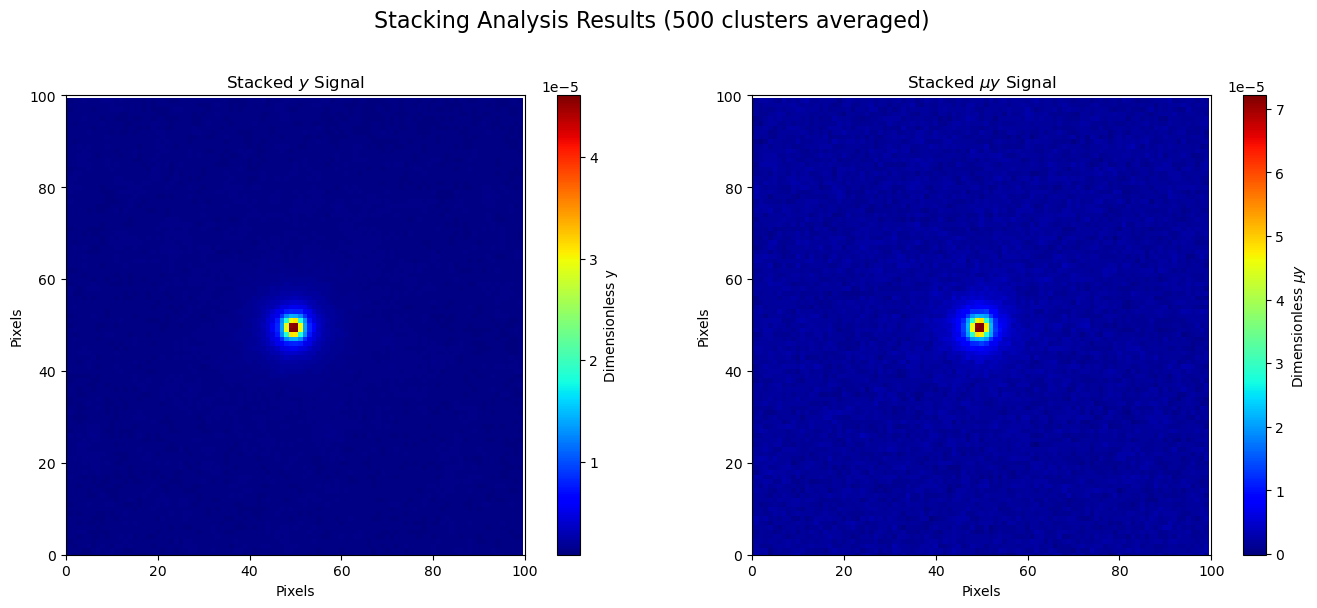

In [27]:
### PLOTING THE STACKED PATCHES ###

# --- Execution ---
# Assuming stack_y_reco and stack_muy_reco are your current stacked results
plot_stacked_patches(stack_y, stack_muy, n_clusters=500, filename="Stacked_Patches_ILC.pdf")

In [ ]:
### PLOTING THE STACKED PATCHES OF THE REAL DATA ###

# --- Execution ---
# Assuming stack_y_reco and stack_muy_reco are your current stacked results
plot_stacked_patches(stack_y_real, stack_muy_real, n_clusters=500, filename="Stacked_Patches_Real_Data.pdf")

### 5.4. Temperature-Temperature plot: $\mu y$ Vs. $y$ and linear regression - the slope represents $\mu$

In [28]:
def plot_tt_correlation(stack_y, stack_muy, filename="TT_Plot.pdf"):
    # Flatten the 2D patches into 1D arrays for regression
    x_data = stack_y.flatten()
    y_data = stack_muy.flatten()
    
    # Linear Regression
    slope, intercept, r_value, p_value, std_err = stats.linregress(x_data, y_data)
    
    # Plotting
    plt.figure(figsize=(8, 6))
    plt.scatter(x_data, y_data, alpha=0.5, s=5, label='Cluster Pixels')
    
    # Plot the regression line
    line = slope * x_data + intercept
    #plt.plot(x_data, line, color='red', label=f'Fit: slope={slope:.2e}')
    plt.plot(x_data, line, color='red', label=rf'$\mu$ = {slope:.2e}')

    # Limit the axes to focus on the cluster signal range
    #plt.xlim(0, 1e-5)
    #plt.ylim(0, 1e-5)

    plt.xlabel(rf'Stacked $y$ Signal')
    plt.ylabel(rf'Stacked $\mu y$ Signal')
    plt.title(rf'T-T Plot: $\mu y$ Vs. $y$ Correlation')
    plt.legend()
    plt.grid(True)
    plt.tight_layout()
    plt.savefig(f"Figures/ILC/{filename}", dpi=300, bbox_inches='tight')
    plt.show()
    
    return slope, intercept, r_value, p_value, std_err

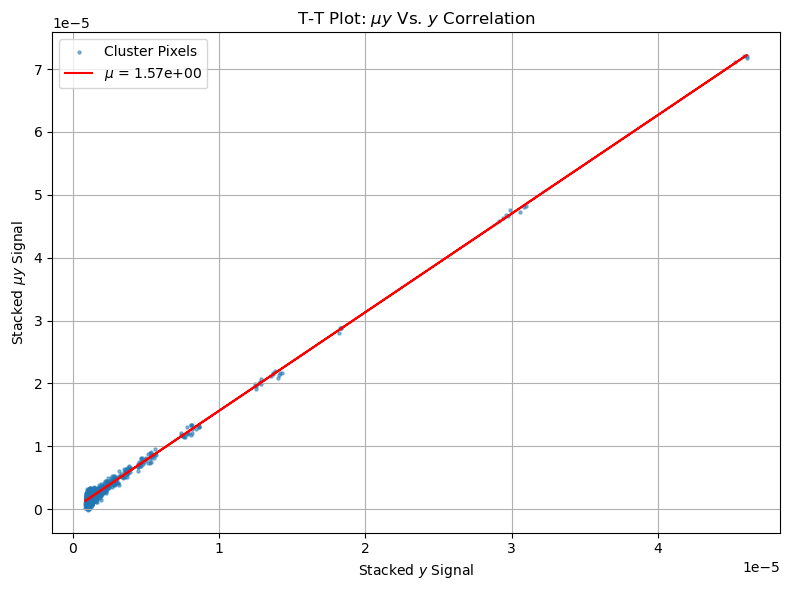

--- Statistics ---
y = 1.57e+00 * x + -6.14e-09
R-squared: 0.9600, p-value: 0.00e+00, std_err: 3.20e-03
----------------------
Measured mu = 1.57e+00
Input    mu = 2.00e-08


In [29]:
### PLOTTING THE ILC T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE ###

measured_mu, intercept, r_value, p_value, std_err = plot_tt_correlation(stack_y, stack_muy, filename="TT_Plot_ILC.pdf")
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("----------------------")
print(f"Measured mu = {measured_mu:.2e}")
print(f"Input    mu = 2.00e-08")

In [ ]:
### PLOTTING THE REAL T-T CORRELATION AND EXTRACTING THE MEASURED MU VALUE ###

measured_mu, intercept, r_value, p_value, std_err = plot_tt_correlation(stack_y_real, stack_muy_real, filename="TT_Plot_Real_Data.pdf")
print(f"--- Statistics ---")
print(rf"y = {measured_mu:.2e} * x + {intercept:.2e}")
print(f"R-squared: {r_value**2:.4f}, p-value: {p_value:.2e}, std_err: {std_err:.2e}")
print("----------------------")
print(f"Measured mu = {measured_mu:.2e}")
print(f"Input    mu = 2.00e-08")